In [42]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import datetime
import pickle
import pandas as pd
from scipy import stats

import geopandas as gpd

from shapely.geometry import Polygon
from matplotlib.colors import ListedColormap
import os
import pickle

In [4]:
data = pd.read_pickle('C:\PROJECT-DEMETER\VAE-Image\\Up_Orbits-max-val-location.pkl')

<>:1: SyntaxWarning: invalid escape sequence '\P'
<>:1: SyntaxWarning: invalid escape sequence '\P'
C:\Users\mbabu\AppData\Local\Temp\ipykernel_89052\286915373.py:1: SyntaxWarning: invalid escape sequence '\P'
  data = pd.read_pickle('C:\PROJECT-DEMETER\VAE-Image\\Up_Orbits-max-val-location.pkl')


In [38]:


def model_func(t, a, b, c, d, e):
    return a + t*b + c * np.sin((2 * np.pi * t) / d + e)

def calculate_filtered_stats(data, column):
    mean_value = data[column].mean()
    conf_interval = stats.norm.interval(0.90, loc=mean_value, scale=np.std(data[column]))
    filtered_data = data[(data[column] >= conf_interval[0]) & (data[column] <= conf_interval[1])]

    if filtered_data.empty:
        filtered_data = data

    mean_filtered = filtered_data[column].mean()
    std_filtered = np.std(filtered_data[column]) / np.sqrt(len(filtered_data[column]))

    return mean_filtered, std_filtered

def fit_and_plot_data(specific_key, min_samples, target, window_size, d, e):
    all_band_values = {}
    total_samples = sum(len(grid_data) for grid_data in data[specific_key])

    if total_samples <= min_samples:
        return  # Exit if total samples are insufficient

    for grid_data in data[specific_key]:
        for band_key, band_data in grid_data.items():
            if band_key == target: 
                if band_key in all_band_values:
                    all_band_values[band_key].append(band_data)
                else:
                    all_band_values[band_key] = [band_data]

    grid_data_dict = {}
    for band_key, band_values in all_band_values.items():
        datetime_values = [pd.to_datetime(entry['datetime']) for entry in band_values]
        q1_values = [entry['Q1'] for entry in band_values]
        q2_values = [entry['Q2'] for entry in band_values]
        q3_values = [entry['Q3'] for entry in band_values]
        max_values = [entry['max'] for entry in band_values]

        df = pd.DataFrame({
            'datetime': datetime_values,
            'Q1': q1_values,
            'Q2': q2_values,
            'Q3': q3_values,
            'max': max_values
        })

        df.set_index('datetime', inplace=True)

        # Resample the DataFrame to specified window size
        resampled_groups = df.resample(window_size)
        window_data = {window: group for window, group in resampled_groups}

        results = []

        for key, dat in window_data.items():
            dat = dat.dropna(subset=['Q1', 'Q2', 'Q3', 'max'])

            if not dat.empty and len(dat) >= 2:
                mean_std_results = {}
                for column in ['Q1', 'Q2', 'Q3', 'max']:
                    mean_filtered, std_filtered = calculate_filtered_stats(dat, column)
                    mean_std_results[f'mean_{column}'] = mean_filtered
                    mean_std_results[f'std_{column}'] = std_filtered

                mean_std_results['window'] = key
                results.append(mean_std_results)

        if len(results) < 25:  # Adjust the threshold as needed
            print(f"Ignoring specific_key: {specific_key}, not enough data points after resampling")
            continue

        resampled_df = pd.DataFrame(results)
        resampled_df.dropna(inplace=True)

        # Convert datetime index to numeric for fitting
        t_data = resampled_df['window']
        timestamp_data = pd.to_datetime(t_data)
        timestamp_values = timestamp_data.to_numpy().astype('datetime64[s]').astype('int')
        t = (timestamp_values - timestamp_values[0]) / (24 * 3600)  # convert to days

        q_resampled = {}
        q_std = {}
        for column in ['Q1', 'Q2', 'Q3', 'max']:
            q_resampled[column] = resampled_df[f'mean_{column}'].values
            q_std[column] = resampled_df[f'std_{column}'].values
            
            # Add epsilon to sigma to prevent division by zero
            epsilon = 1e-8
            q_std[column] = np.where(q_std[column] == 0, epsilon, q_std[column])

            # Check for NaN/Infinite values
            if np.any(np.isnan(q_resampled[column])) or np.any(np.isnan(q_std[column])) or np.any(np.isinf(q_resampled[column])) or np.any(np.isinf(q_std[column])):
                print(f"NaN/Inf detected in {column} for specific_key: {specific_key}")
                continue

        initial_guess = {}
        for column in ['Q1', 'Q2', 'Q3', 'max']:
            initial_guess[column] = [
                np.mean(q_resampled[column]),
                (q_resampled[column][-1] - q_resampled[column][0]) / len(q_resampled[column]),
                (q_resampled[column].max() - q_resampled[column].min()) / 2,
                d,
                e
            ]
            print(f"Initial guess for {column}: {initial_guess[column]}")

        lower_bounds = [-np.inf, -np.inf, 0, 365.25, -np.inf]
        upper_bounds = [np.inf, np.inf, 3.0, 365.2500001, np.inf]

        popt = {}
        pcov = {}

        band_data_dict = {}
        for column in ['Q1', 'Q2', 'Q3', 'max']:
            try:
                popt[column], pcov[column] = curve_fit(
                    model_func,
                    t,
                    q_resampled[column],
                    p0=initial_guess[column],
                    sigma=q_std[column],
                    maxfev=650000,
                    bounds=(lower_bounds, upper_bounds)
                )
                a, b, c, d, e = popt[column]
                y_fit = model_func(t, a, b, c, d, e)

                chi_square = np.sum(((q_resampled[column] - y_fit) / q_std[column]) ** 2)
                dof = len(q_resampled[column]) - len(popt[column])
                reduced_chi_square = chi_square / dof

                band_data_dict[column] = {
                    'coefficients': [a, b, c, d, e], 
                    'y_fit': y_fit.tolist(), 
                    'chi_square': reduced_chi_square
                }
            except RuntimeError as err:
                print(f"Error in fitting {column} for specific_key: {specific_key}: {err}")
                continue

        grid_data_dict[band_key] = band_data_dict

    all_data[specific_key] = grid_data_dict

    with open(f"C:/PROJECT-DEMETER/Anomaly/GRID-Method/GRID-FB-UP_ICE/set1-{target}.pkl", "wb") as f:
        pickle.dump(all_data, f)


In [39]:
# Assuming data is your dictionary
filtered_keys = [key for key in data.keys() if 19 <= int(key[1:]) <= 145 ]



In [40]:

# set4 , 3
for target in ['fb_1','fb_2', 'fb_3','fb_4','fb_5','fb_6','fb_7','fb_8' ,'fb_9', 'fb_10', 'fb_11']:
    for specific_key in filtered_keys:
        print(specific_key)
        fit_and_plot_data(specific_key, 100, target,  '30D', 365.25, np.pi)


G27


Initial guess for Q1: [-0.39379035433991105, -0.003868517439591446, 0.6429181199885138, 365.25, 3.141592653589793]
Initial guess for Q2: [-0.03556250073747059, -0.0058080589853847404, 0.7130600072964179, 365.25, 3.141592653589793]
Initial guess for Q3: [0.42441957196415975, -0.005679074844533305, 0.9338516512854969, 365.25, 3.141592653589793]
Initial guess for max: [1.4523345622007255, -0.006181280260643507, 1.188339101156719, 365.25, 3.141592653589793]
G26
Initial guess for Q1: [-0.6569284988034608, -0.005226127148750145, 0.6309549925358718, 365.25, 3.141592653589793]
Initial guess for Q2: [-0.37619988757690487, -0.00563600176535115, 0.6777337813284248, 365.25, 3.141592653589793]
Initial guess for Q3: [0.009092999581800178, -0.009209853381138574, 0.8187970123341624, 365.25, 3.141592653589793]
Initial guess for max: [1.0535952916684286, -0.00937574895371627, 0.9655915996196335, 365.25, 3.141592653589793]
G44
Initial guess for Q1: [-1.0280921102063436, -0.0014545102292811262, 0.50468548

c:\Users\mbabu\AppData\Local\anaconda3\envs\DL\Lib\site-packages\scipy\stats\_distn_infrastructure.py:2244: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
c:\Users\mbabu\AppData\Local\anaconda3\envs\DL\Lib\site-packages\scipy\stats\_distn_infrastructure.py:2245: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc


Initial guess for Q1: [0.8461921249109527, -0.011678367603677957, 0.9577205946975895, 365.25, 3.141592653589793]
Initial guess for Q2: [1.3721675086399965, -0.01585659908649584, 1.1072489395737648, 365.25, 3.141592653589793]
Initial guess for Q3: [1.9028784045082565, -0.017423436108018345, 1.258496728663643, 365.25, 3.141592653589793]
Initial guess for max: [2.8450242683040536, -0.012006657852974114, 1.4104652106761932, 365.25, 3.141592653589793]
G19
Initial guess for Q1: [1.0025794928826213, -0.006568851618855131, 1.6596850816329771, 365.25, 3.141592653589793]
Initial guess for Q2: [1.5774122849805219, -0.01085052956708604, 1.8629092787608, 365.25, 3.141592653589793]
Initial guess for Q3: [2.1700246365863447, -0.013446388588774774, 1.932611540208412, 365.25, 3.141592653589793]
Initial guess for max: [3.329230762850341, 0.00044014068389472454, 1.8507625483014065, 365.25, 3.141592653589793]
G108
Initial guess for Q1: [-0.9842523183931016, 0.0013604760476171166, 0.3608700144731876, 365.2

c:\Users\mbabu\AppData\Local\anaconda3\envs\DL\Lib\site-packages\scipy\stats\_distn_infrastructure.py:2244: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
c:\Users\mbabu\AppData\Local\anaconda3\envs\DL\Lib\site-packages\scipy\stats\_distn_infrastructure.py:2245: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc


Initial guess for Q1: [-1.3220040004595393, -0.009956180428465208, 1.1838069196258272, 365.25, 3.141592653589793]
Initial guess for Q2: [-1.0754262510866912, -0.009688314878278308, 1.1931373125097404, 365.25, 3.141592653589793]
Initial guess for Q3: [-0.7995104590849618, -0.010758529055035777, 1.1714725484450659, 365.25, 3.141592653589793]
Initial guess for max: [0.4878311222342885, 0.001446470767000897, 0.9327910927434763, 365.25, 3.141592653589793]
G131
Initial guess for Q1: [-0.559852906322173, -0.0034101520136248214, 1.689520601183176, 365.25, 3.141592653589793]
Initial guess for Q2: [-0.30349917775211427, -0.006834251270310518, 1.6122777685523033, 365.25, 3.141592653589793]
Initial guess for Q3: [0.019028764620198802, -0.013160064181417816, 1.5352457493543625, 365.25, 3.141592653589793]
Initial guess for max: [1.1091948164335759, -0.013749536075820662, 1.3520703054964542, 365.25, 3.141592653589793]
G19
Initial guess for Q1: [-0.8379067171031959, -0.026238398235945773, 1.0048448357

In [ ]:
d = pd.read_pickle("C:/PROJECT-DEMETER/Anomaly/GRID-Method/GRID-FB-UP_ICE/set1-fb_1.pkl")

In [129]:
import pandas as pd


grid_ids = []
band_keys = []
q_keys = []
coefficients_a = []
coefficients_b = []
coefficients_c = []
coefficients_d = []
coefficients_e = []
y_fit= []
chi = []
datetime = []


for grid_id, grid_data in d.items():
    for band_key, band_data in grid_data.items():
        for q_key, q_data in band_data.items():
            if 'coefficients' in q_data:
                coefficients = q_data['coefficients']
                grid_ids.append(grid_id)
                band_keys.append(band_key)
                q_keys.append(q_key)
                coefficients_a.append(coefficients[0])
                coefficients_b.append(coefficients[1])
                coefficients_c.append(coefficients[2])
                coefficients_d.append(coefficients[3])
                coefficients_e.append(coefficients[4])
                y_fit.append(q_data['y_fit'])
                chi.append(q_data['chi_square'])
                # datetime.append(q_data['datetime'])


df = pd.DataFrame({
    'Grid_ID': grid_ids,
    'Band_Key': band_keys,
    'Q_Key': q_keys,
    'Intercept': coefficients_a,
    'slope': coefficients_b,
    'Amplitude': coefficients_c,
    'Period': coefficients_d,
    'Phase': coefficients_e,
    'Y_fit': y_fit,
    'reduced-chi': chi
    # 'datetime':datetime
})

print(df)


     Grid_ID Band_Key Q_Key  Intercept     slope  Amplitude    Period  \
0       G144     fb_1    Q1  -0.422404 -0.000087   0.101463  0.016928   
1       G144     fb_1    Q2  -0.130783 -0.000073   0.090229  0.016878   
2       G144     fb_1    Q3   0.254573 -0.000055   0.093290  0.016639   
3       G144     fb_2    Q1  -0.735090 -0.000438   0.045172  0.015986   
4       G144     fb_2    Q2  -0.491036 -0.000442   0.044162  0.015972   
...      ...      ...   ...        ...       ...        ...       ...   
4681    G155    fb_10    Q2  -1.773924 -0.000516   0.722892  0.058515   
4682    G155    fb_10    Q3  -4.305515  0.005804   3.063824  0.022497   
4683    G155    fb_11    Q1  -4.396617  0.005188   2.257772  0.021925   
4684    G155    fb_11    Q2  -4.200794  0.005084   2.243797  0.021878   
4685    G155    fb_11    Q3  -4.072927  0.005161   2.354373  0.021974   

         Phase                                              Y_fit  reduced-chi  
0     2.337945  [-0.3493615560107382, -0.3

In [130]:
df['Grid_ID'].unique()


array(['G144', 'G125', 'G107', 'G89', 'G71', 'G52', 'G161', 'G143',
       'G142', 'G124', 'G106', 'G88', 'G69', 'G51', 'G160', 'G141',
       'G123', 'G105', 'G86', 'G68', 'G50', 'G32', 'G159', 'G140', 'G122',
       'G103', 'G85', 'G67', 'G49', 'G30', 'G158', 'G139', 'G120', 'G102',
       'G84', 'G66', 'G47', 'G29', 'G138', 'G137', 'G119', 'G101', 'G83',
       'G65', 'G64', 'G46', 'G28', 'G135', 'G117', 'G98', 'G80', 'G62',
       'G44', 'G26', 'G25', 'G7', 'G134', 'G116', 'G115', 'G97', 'G79',
       'G61', 'G43', 'G42', 'G24', 'G132', 'G114', 'G96', 'G78', 'G60',
       'G59', 'G41', 'G23', 'G4', 'G131', 'G113', 'G95', 'G77', 'G76',
       'G58', 'G40', 'G22', 'G21', 'G130', 'G112', 'G94', 'G93', 'G75',
       'G57', 'G39', 'G20', 'G129', 'G111', 'G110', 'G92', 'G74', 'G56',
       'G38', 'G37', 'G19', 'G128', 'G109', 'G91', 'G73', 'G55', 'G72',
       'G54', 'G36', 'G127', 'G126', 'G108', 'G90', 'G53', 'G35', 'G70',
       'G87', 'G104', 'G31', 'G100', 'G82', 'G27', 'G136', 'G11

In [267]:

q = 'Q1'
Band_Key = 'fb_1'
# Filter the DataFrame for the specific conditions
new_df = df[(df['Band_Key'] == Band_Key) & (df['Q_Key'] == q)]

# Keep only the required columns
new_df = new_df[['Grid_ID', 'Band_Key', 'Q_Key', 'Intercept', 'slope', 'Amplitude', 'Period','Phase', 'reduced-chi']]

# Reset the index of the new DataFrame
new_df.reset_index(drop=True, inplace=True)
new_df = new_df.set_index('Grid_ID')
print(new_df)


    Grid_ID Band_Key Q_Key  Intercept     slope  Amplitude    Period  \
0      G144     fb_1    Q1  -0.422404 -0.000087   0.101463  0.016928   
1      G125     fb_1    Q1  -1.214306  0.000059   0.072720  0.018158   
2      G107     fb_1    Q1  -1.564176  0.000044   0.014381  0.014631   
3       G89     fb_1    Q1  -1.760998  0.000075   0.035810  0.018281   
4       G71     fb_1    Q1  -1.446708  0.000166   0.125621  0.017685   
..      ...      ...   ...        ...       ...        ...       ...   
121    G133     fb_1    Q1  -0.327174 -0.000205   0.224670  0.016734   
122    G121     fb_1    Q1  -1.290845  0.000039   0.093913  0.017165   
123     G48     fb_1    Q1  -0.977950  0.000009   0.249916  0.017603   
124     G33     fb_1    Q1   0.035624  0.000109   0.322686  0.017088   
125     G34     fb_1    Q1  -0.039158 -0.000043   0.005918  0.011333   

        Phase  reduced-chi  
0    2.337945     0.879928  
1    2.044048     0.844882  
2    3.141593     0.966016  
3    3.141593     0

In [41]:


def create_grid(width, depth):

    min_lat, max_lat = -90, 90
    min_lon, max_lon = -180 , 180

    num_lat_cells = int((max_lat - min_lat) / depth)
    num_lon_cells = int((max_lon - min_lon) / width)

    grid = np.empty((num_lat_cells, num_lon_cells), dtype=object)
    
    # Assign IDs to each grid cell
    for lon_idx in range(num_lon_cells):
        for lat_idx in range(num_lat_cells):
            grid[lat_idx, lon_idx] = f'G{lat_idx * num_lon_cells + lon_idx + 1}'

    return grid



C:\Users\mbabu\AppData\Local\Temp\ipykernel_41764\292354745.py:35: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


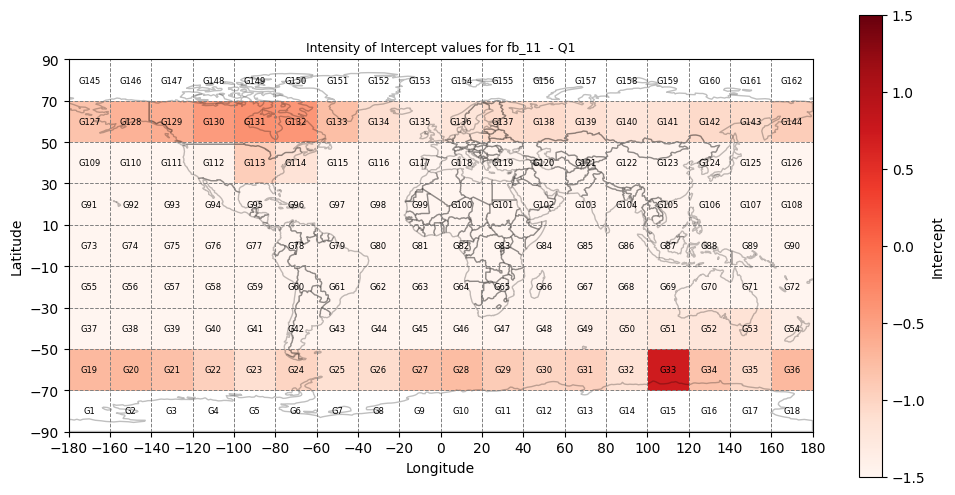

C:\Users\mbabu\AppData\Local\Temp\ipykernel_41764\292354745.py:35: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


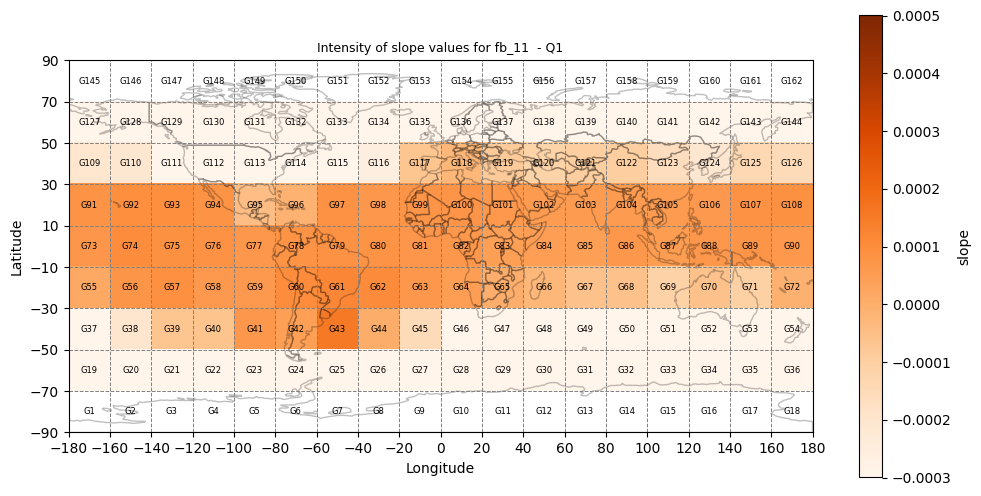

C:\Users\mbabu\AppData\Local\Temp\ipykernel_41764\292354745.py:35: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


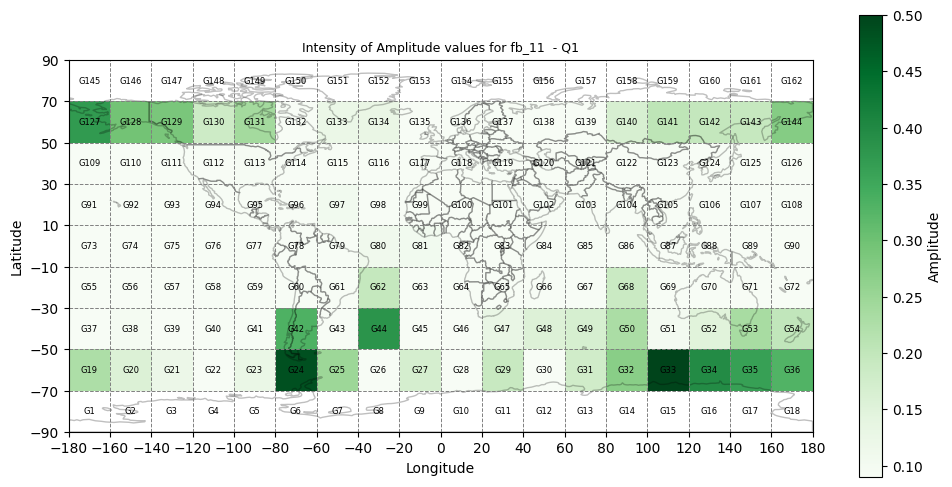

C:\Users\mbabu\AppData\Local\Temp\ipykernel_41764\292354745.py:35: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


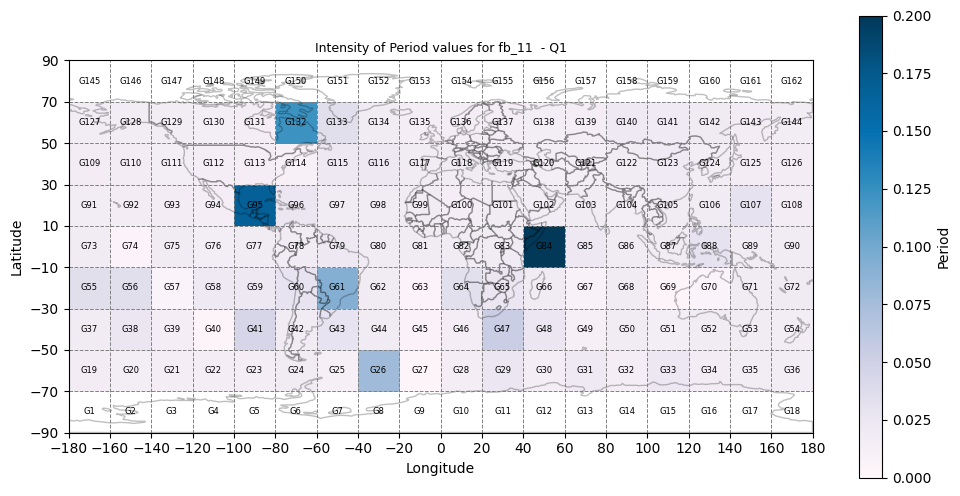

C:\Users\mbabu\AppData\Local\Temp\ipykernel_41764\292354745.py:35: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


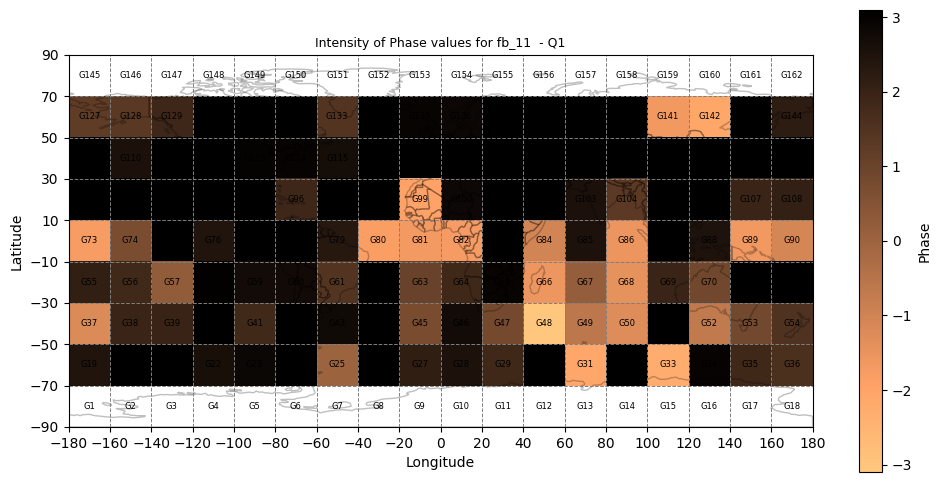

C:\Users\mbabu\AppData\Local\Temp\ipykernel_41764\292354745.py:35: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


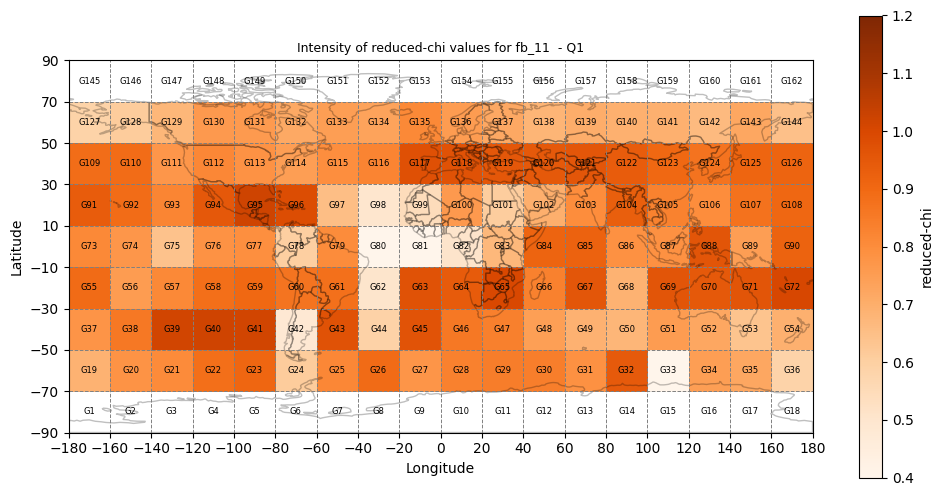

In [276]:


def plot_grid_with_intensity(grid, width, depth, all_data, intensity_column, cmap, vmin, vmax):
    fig, ax = plt.subplots(figsize=(12, 6))

    world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
    world.plot(ax=ax, facecolor='none', edgecolor='black', alpha=0.25, zorder=2)

    for lat in np.arange(-90, 91, depth):
        ax.axhline(y=lat, color='gray', linestyle='--', linewidth=0.7)

    for lon in np.arange(0, 361, width):
        ax.axvline(x=lon - 180, color='gray', linestyle='--', linewidth=0.7)

    intensities = np.zeros(grid.shape)

    for lon_idx in range(grid.shape[1]):
        for lat_idx in range(grid.shape[0]):
            specific_key = grid[lat_idx, lon_idx]
            intensity = all_data.loc[specific_key, intensity_column] if specific_key in all_data.index else np.nan
            intensities[lat_idx, lon_idx] = intensity

    im = ax.imshow(intensities, cmap=cmap, extent=[-180, 180, -90, 90], origin='lower', vmin=vmin, vmax=vmax)

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(intensity_column)

    for lon_idx in range(grid.shape[1]):
        for lat_idx in range(grid.shape[0]):
            lat_start = -90 + lat_idx * depth
            lon_start = lon_idx * width
            ax.text(lon_start + width / 2 - 180, lat_start + depth / 2, grid[lat_idx, lon_idx], ha='center', va='center', color='black', fontsize=6)

    ax.set_xticks(np.arange(-180, 181, 20))
    ax.set_yticks(np.arange(-90, 91, 20))

    ax.set_title(f'Intensity of {intensity_column} values for {Band_Key}  - {q}', fontsize=9)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    folder_path = f"C:\\PROJECT-DEMETER\\Anomaly\\GRID-Method\\Set2-params\\{Band_Key}"

    os.makedirs(folder_path, exist_ok=True)
    # plt.savefig(os.path.join(folder_path, f'{q}_{intensity_column}-set1.png'))
    plt.show()

grid = create_grid(20, 20)
params = ['Intercept', 'slope', 'Amplitude', 'Period', 'Phase', 'reduced-chi']
vmin_vmax = {
    'Intercept': (-1.5, 1.5),
    'slope': (-0.0003, 0.0005),
    'Amplitude': (0.5, 0.1),
    'Period': (0, 0.2),
    'Phase': (-3.1, 3.1),
    'reduced-chi': (0.4, 1.2)
}
colormaps = ['Reds', 'Oranges', 'Greens', 'PuBu', 'copper_r', 'Oranges']

for i, param in enumerate(params):
    cmap = colormaps[i % len(colormaps)]
    vmin, vmax = vmin_vmax[param]
    plot_grid_with_intensity(grid, 20, 20, new_df, param, cmap, vmin, vmax)
